In [1]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import shap

# Load model
tuned_lgb = joblib.load('../models/tuned_lgb_model.joblib')

# Load test data
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("Model loaded successfully!")
print("X_test shape:", X_test.shape)

/home/abood-linux/miniconda3/envs/flight-price-predictor/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded successfully!
X_test shape: (60052, 11)


In [2]:
# Create TreeSHAP explainer
explainer = shap.TreeExplainer(tuned_lgb)

# Calculate SHAP values for test set
# We use a sample of 1000 rows for speed
X_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

print("SHAP values shape:", shap_values.shape)
print("X_sample shape:   ", X_sample.shape)

SHAP values shape: (1000, 11)
X_sample shape:    (1000, 11)


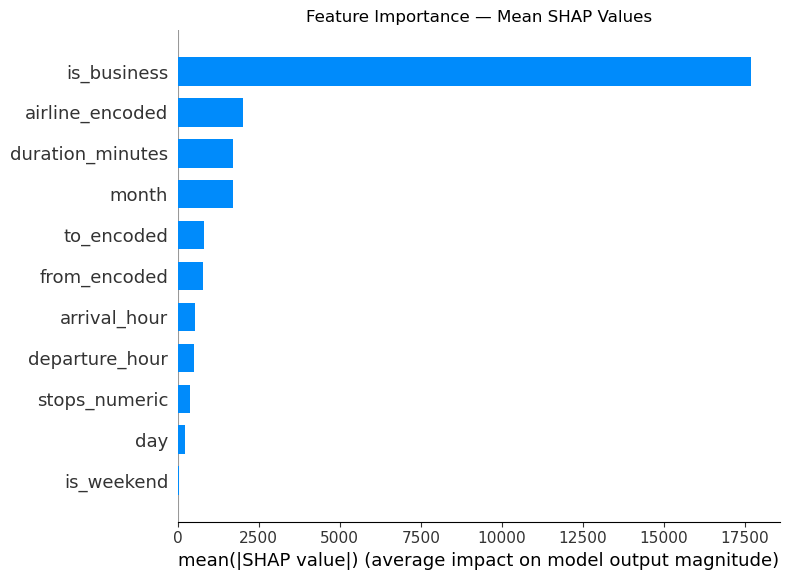

Plot saved!


In [6]:
import os

os.makedirs('../reports/figures', exist_ok=True)

plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar',
    show=False
)
plt.title('Feature Importance — Mean SHAP Values')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

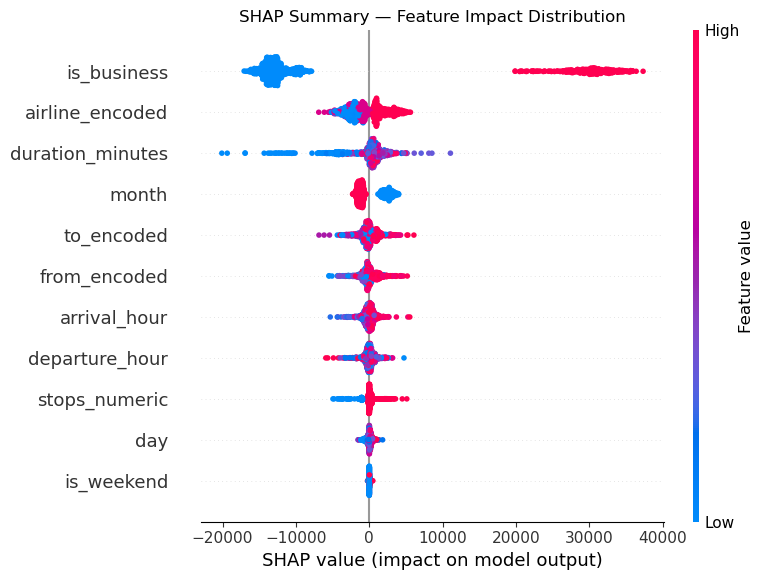

In [7]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)
plt.title('SHAP Summary — Feature Impact Distribution')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary_dot.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Pick one flight from test set
flight_idx = 0
flight = X_sample.iloc[[flight_idx]]

print("Flight details:")
print(flight.T.round(2))
print("\nActual price:   ", y_test.iloc[flight_idx])
print("Predicted price:", round(tuned_lgb.predict(flight)[0], 2))

Flight details:
                      5931
stops_numeric         2.00
duration_minutes    510.00
departure_hour       10.00
arrival_hour         19.00
month                 3.00
day                   6.00
is_weekend            1.00
is_business           0.00
airline_encoded   30428.84
from_encoded      21914.56
to_encoded        21619.01

Actual price:    4515
Predicted price: 7992.35


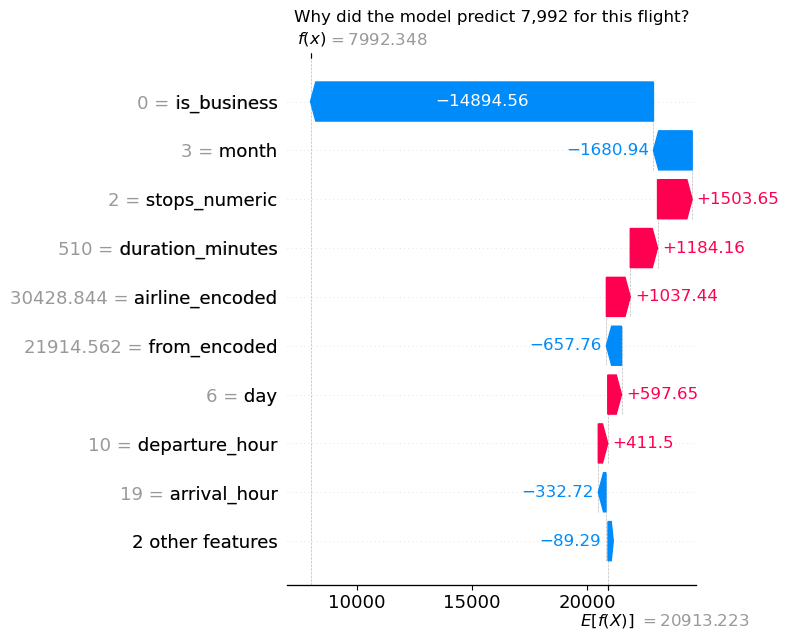

In [13]:
# Get SHAP values for this specific flight
shap_single = explainer.shap_values(flight)

# Waterfall plot
shap.waterfall_plot(
    shap.Explanation(
        values=shap_single[0],
        base_values=explainer.expected_value,
        data=flight.iloc[0],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title('Why did the model predict 7,992 for this flight?')
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()